# 02 — TWFE DiD and Event Study

Baseline two-way fixed effects regression of unemployment on log(minimum wage), plus an event-study specification to check the parallel-trends assumption.

In [1]:
import sys
sys.path.insert(0, r"C:\Users\thoma\minimum-wage-causal-inference")


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.twfe_did import estimate_twfe, summarize_twfe

panel, is_synthetic = load_state_year_panel()
result = estimate_twfe(panel)
print(result.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      unemployment_rate   R-squared:                        0.0081
Estimator:                   PanelOLS   R-squared (Between):             -0.0644
No. Observations:                 380   R-squared (Within):               0.0142
Date:                Tue, Jul 14 2026   R-squared (Overall):             -0.0640
Time:                        21:26:43   Log-likelihood                    308.65
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.7785
Entities:                          20   P-value                           0.0965
Avg Obs:                       19.000   Distribution:                   F(1,341)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             2.1323
                            

In [3]:
summarize_twfe(result)

,coef,std_error,pvalue,ci_lower,ci_upper
log_minimum_wage,-0.09446,0.064688,0.145142,-0.221697,0.032777


## Event study

In [4]:
from src.methods.event_study import estimate_event_study

_, es_summary = estimate_event_study(panel)
es_summary

,rel_time,coef,ci_lower,ci_upper
0,-5,0.000061,-0.111321,0.111443
1,-4,0.050960,-0.040645,0.142565
2,-3,0.049004,-0.029858,0.127866
3,-2,0.058441,-0.030724,0.147606
4,-1,0.000000,0.000000,0.000000
5,0,0.081014,0.006779,0.155248
6,1,-0.015885,-0.110724,0.078954
7,2,-0.021216,-0.164639,0.122206
8,3,-0.016431,-0.135743,0.102882
9,4,-0.054566,-0.174373,0.065241


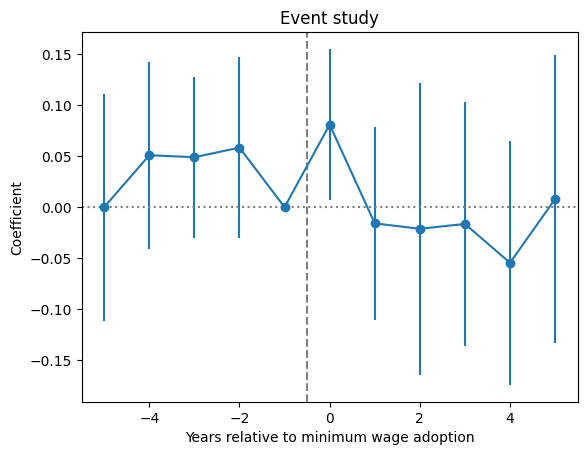

In [5]:
import matplotlib.pyplot as plt

plt.errorbar(es_summary.rel_time, es_summary.coef,
             yerr=[es_summary.coef - es_summary.ci_lower, es_summary.ci_upper - es_summary.coef],
             fmt='o-')
plt.axvline(-0.5, color='gray', linestyle='--')
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Years relative to minimum wage adoption'); plt.ylabel('Coefficient')
plt.title('Event study'); plt.show()

## Pre-trend check

In [6]:
from src.diagnostics.parallel_trends import pretrend_joint_test

pretrend_joint_test(es_summary)

{'n_pre_periods': 5,
 'n_significant_violations': 0,
 'violating_periods': [],
 'passes': True}